In [1]:
import os
import cv2
import numpy as np

def ensure_dir(directory):
    """Создает папку, если ее не существует."""
    if not os.path.exists(directory):
        os.makedirs(directory)

def binarize_and_clean(window, method='otsu'):
    """
    Бинаризует фрагмент изображения и применяет морфологическую очистку.
    Возвращает бинарное изображение window_bin.
    
    Параметры:
      window - фрагмент в градациях серого
      method - 'otsu' (глобальный порог Оцу) или 'adaptive' (адаптивный порог)

    Дополнительно можно настроить морф. операции и ядро по вкусу.
    """
    # Бинаризация
    if method == 'adaptive':
        # Адаптивный порог
        window_bin = cv2.adaptiveThreshold(window, 255,
                                           cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                           cv2.THRESH_BINARY, 11, 2)
    else:
        # Otsu
        _, window_bin = cv2.threshold(window, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # Морфологическая очистка (пример: открытие, потом закрытие)
    kernel = np.ones((3,3), np.uint8)
    opened = cv2.morphologyEx(window_bin, cv2.MORPH_OPEN, kernel)
    cleaned = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)
    return cleaned

def sliding_window_morph_diff(f_img, g_img, window_size=32, step=16,
                              diff_threshold=0.3, bin_method='otsu'):
    """
    Вариант 2 (скользящее окно + чисто морфологическое выделение отличий).
    
    Для каждого окна:
      1) Бинаризация фрагментов f_win и g_win + морф. очистка
      2) Морфологическая (бинарная) симметрическая разность
      3) Если доля белых пикселей в разности > diff_threshold => отличие

    Параметры:
      f_img, g_img       - изображения одинакового размера (градации серого)
      window_size        - размер окна (в пикселях)
      step               - шаг скольжения окна (может быть меньше window_size)
      diff_threshold     - порог доли отличающихся пикселей (0..1)
      bin_method         - 'otsu' или 'adaptive' (метод пороговой бинаризации)

    Возвращает:
      - result: цветная копия f с пометками красным
      - diff_map: карта (0/255), где окна с превышающей порог разницей помечаются белым
    """
    h, w = f_img.shape[:2]
    # Для визуализации сделаем BGR-копию f
    result = cv2.cvtColor(f_img, cv2.COLOR_GRAY2BGR)
    diff_map = np.zeros_like(f_img, dtype=np.uint8)
    
    for y in range(0, h - window_size + 1, step):
        for x in range(0, w - window_size + 1, step):
            # Фрагменты
            f_win = f_img[y:y+window_size, x:x+window_size]
            g_win = g_img[y:y+window_size, x:x+window_size]
            
            # Бинаризация и морфологическая очистка
            f_bin = binarize_and_clean(f_win, method=bin_method)
            g_bin = binarize_and_clean(g_win, method=bin_method)
            
            # Симметрическая разность
            # diff = (f_bin AND NOT g_bin) OR (g_bin AND NOT f_bin)
            diff_fg = cv2.bitwise_and(f_bin, cv2.bitwise_not(g_bin))
            diff_gf = cv2.bitwise_and(g_bin, cv2.bitwise_not(f_bin))
            sym_diff = cv2.bitwise_or(diff_fg, diff_gf)
            
            # Доля белых пикселей
            diff_norm = np.sum(sym_diff > 0) / float(window_size * window_size)
            
            if diff_norm > diff_threshold:
                # Отмечаем центр окна на result
                center_x = x + window_size // 2
                center_y = y + window_size // 2
                cv2.circle(result, (center_x, center_y), radius=3, color=(0,0,255), thickness=-1)
                # Заливаем окно белым на карте diff_map
                diff_map[y:y+window_size, x:x+window_size] = 255
    
    return result, diff_map

def main():
    # Пути к изображениям f и g
    f_path = os.path.join("source_images", "f.png")
    g_path = os.path.join("source_images", "g.png")
    
    if not os.path.exists(f_path) or not os.path.exists(g_path):
        print("Не найдены f.png / g.png в папке source_images.")
        return
    
    f_img = cv2.imread(f_path, cv2.IMREAD_GRAYSCALE)
    g_img = cv2.imread(g_path, cv2.IMREAD_GRAYSCALE)
    
    if f_img is None or g_img is None:
        print("Ошибка загрузки изображений.")
        return
    
    # Проверяем, что размеры совпадают
    if f_img.shape != g_img.shape:
        print("Размеры f и g не совпадают.")
        return
    
    # Параметры скользящего окна
    window_size = 32
    step = 16
    
    # Пороговая доля отличий
    diff_threshold = 0.3
    
    # Вычисляем карту отличий
    result_img, diff_map = sliding_window_morph_diff(
        f_img, g_img,
        window_size=window_size,
        step=step,
        diff_threshold=diff_threshold,
        bin_method='otsu'  # или 'adaptive'
    )
    
    # Сохраним результаты
    out_dir = "results/task8_variant2_morph"
    ensure_dir(out_dir)
    
    cv2.imwrite(os.path.join(out_dir, "result.png"), result_img)
    cv2.imwrite(os.path.join(out_dir, "diff_map.png"), diff_map)
    
    print("Обработка завершена. Результаты сохранены в:", out_dir)

if __name__ == "__main__":
    main()


Обработка завершена. Результаты сохранены в: results/task8_variant2_morph


[info] δ‑map size 67×120, time=3.02s
Saved → diff_mask.png
Saved → delta_map.png


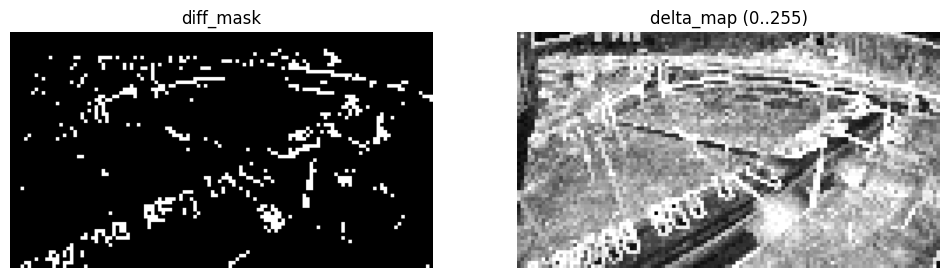

In [20]:
import cv2
import numpy as np
import time
import matplotlib.pyplot as plt

# --- Параметры (пропишите свои файлы и желаемые block_size/threshold) ---
path_f       = "source_images/f.png"
path_g       = "source_images/g.png"
block_size   = 16     # например, 32
delta_thresh = 127.4    # подберите по вкусу

# --- Функции из нашего скрипта ---
def is_feasible(g_sorted: np.ndarray, e: float) -> bool:
    y_prev = -np.inf
    low  = g_sorted - e
    high = g_sorted + e
    for li, hi in zip(low, high):
        y = max(li, y_prev)
        if y > hi:
            return False
        y_prev = y
    return True

def compute_delta(block_f: np.ndarray, block_g: np.ndarray, tol: float = 1e-3) -> float:
    f_flat = block_f.ravel().astype(np.float32)
    g_flat = block_g.ravel().astype(np.float32)
    idx     = np.argsort(f_flat)
    g_sorted= g_flat[idx]
    lo, hi = 0.0, (g_sorted.max() - g_sorted.min())
    while hi - lo > tol:
        mid = 0.5 * (lo + hi)
        if is_feasible(g_sorted, mid):
            hi = mid
        else:
            lo = mid
    return hi

def detect_shape_diff(img_f, img_g, block_size, delta_thresh):
    H0, W0 = img_f.shape
    H = (H0 // block_size) * block_size
    W = (W0 // block_size) * block_size
    img_f = img_f[:H, :W]
    img_g = img_g[:H, :W]

    n_by = H // block_size
    n_bx = W // block_size

    delta_map = np.zeros((n_by, n_bx), dtype=np.float32)
    diff_mask = np.zeros((H, W), dtype=np.uint8)

    t0 = time.time()
    for by in range(n_by):
        for bx in range(n_bx):
            y0 = by * block_size
            x0 = bx * block_size
            bf = img_f[y0:y0+block_size, x0:x0+block_size]
            bg = img_g[y0:y0+block_size, x0:x0+block_size]
            d = compute_delta(bf, bg)
            delta_map[by, bx] = d
            if d > delta_thresh:
                diff_mask[y0:y0+block_size, x0:x0+block_size] = 255
    print(f"[info] δ‑map size {n_by}×{n_bx}, time={(time.time() - t0):.2f}s")
    return delta_map, diff_mask

def save_and_expand(delta_map, diff_mask, block_size):
    # сохраняем маску отличий
    cv2.imwrite("diff_mask.png", diff_mask)
    print("Saved → diff_mask.png")

    # расширяем δ-карту до full-size
    delta_full = np.kron(delta_map, np.ones((block_size, block_size), dtype=np.float32))
    # нормируем в [0..255]
    ptp_val = np.ptp(delta_full)                # <-- use top-level np.ptp
    dm = 255.0 * (delta_full - delta_full.min()) / (ptp_val + 1e-8)
    dm8 = dm.astype(np.uint8)
    cv2.imwrite("delta_map.png", dm8)
    print("Saved → delta_map.png")
    return dm8

# --- Основной блок ---
# 1) Читать
f = cv2.imread(path_f, cv2.IMREAD_GRAYSCALE)
g = cv2.imread(path_g, cv2.IMREAD_GRAYSCALE)
assert f is not None and g is not None, "Невозможно загрузить кадры!"

# 2) Считать δ‑карту и маску
delta_map, diff_mask = detect_shape_diff(f, g, block_size, delta_thresh)

# 3) Сохранить и получить растянутую δ‑карту
delta_full_uint8 = save_and_expand(delta_map, diff_mask, block_size)

# 4) Показать inline через matplotlib
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
ax1.imshow(diff_mask, cmap="gray")
ax1.set_title("diff_mask")
ax1.axis("off")
ax2.imshow(delta_full_uint8, cmap="gray")
ax2.set_title("delta_map (0..255)")
ax2.axis("off")
plt.show()


[info] δ‑map size 67×120, time=3.10s
δ min, max, mean: 0.0 127.5 76.90248
δ percentiles: [ 79.00048447 100.50030899 122.0007164  127.5        127.5       ]


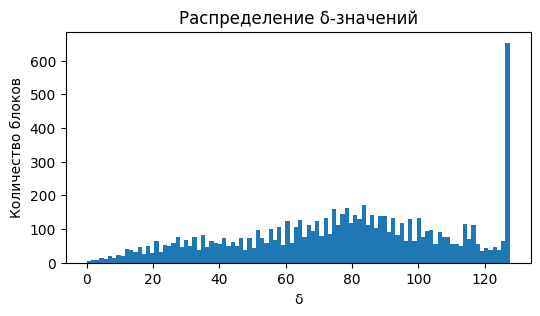

In [21]:
import numpy as np
import matplotlib.pyplot as plt

delta_map, _ = detect_shape_diff(f, g, block_size, delta_thresh)

print("δ min, max, mean:", delta_map.min(), delta_map.max(), delta_map.mean())
print("δ percentiles:", np.percentile(delta_map, [50,75,90,95,99]))

plt.figure(figsize=(6,3))
plt.hist(delta_map.ravel(), bins=100)
plt.title("Распределение δ-значений")
plt.xlabel("δ")
plt.ylabel("Количество блоков")
plt.show()
